In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df = pd.read_csv("Churn.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Data Cleaning

In [11]:
df.isnull().sum() # Check for missing values

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
df.drop_duplicates(inplace=True) # Remove duplicate entries

Drop unnecessary columns (if present):

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')


In [14]:
# Convert categorical fields
df['Gender'] = df['Gender'].astype('category')
df['Geography'] = df['Geography'].astype('category')

Exploratory Data Analysis (EDA)

In [15]:
df.describe() # Statistical summary

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


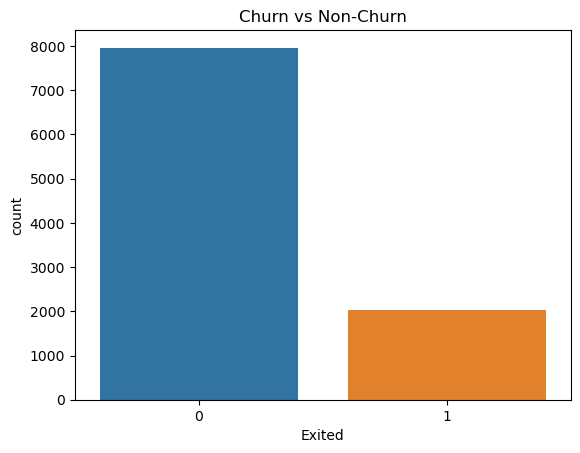

In [17]:
# Churn distribution
df['Exited'].value_counts()
sns.countplot(x='Exited', data=df)
plt.title("Churn vs Non-Churn")
plt.show()

Attribute-Wise Churn Analysis

<Axes: xlabel='Exited', ylabel='Age'>

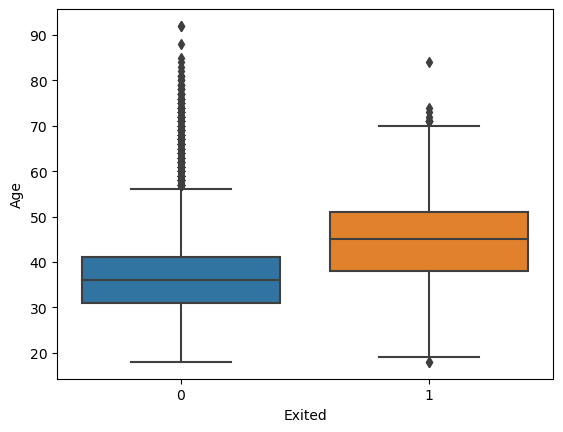

In [28]:
# 1. Age distribution by churn status(age vs churn)
sns.boxplot(x='Exited', y='Age', data=df) 

<Axes: xlabel='Exited', ylabel='Balance'>

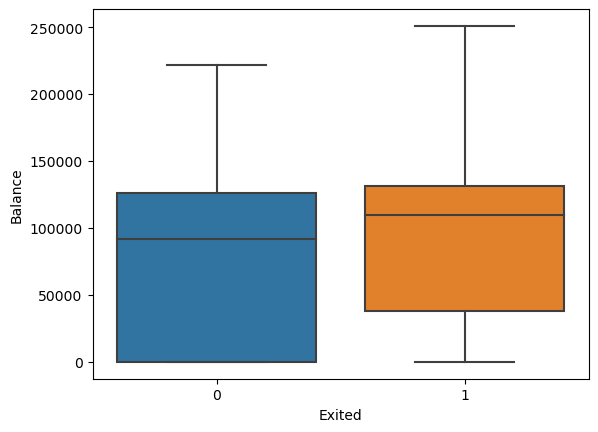

In [29]:
# 2. Balance distribution by churn status (Balance vs Churn)
sns.boxplot(x='Exited', y='Balance', data=df) 

<Axes: xlabel='Exited', ylabel='Tenure'>

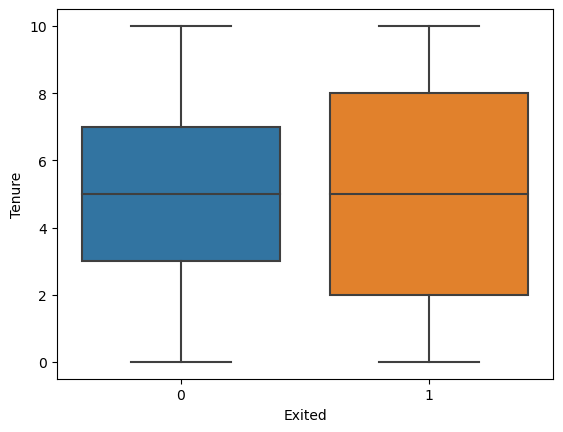

In [ ]:
# 3. Tenure distribution by churn status(Tenure vs Churn)
sns.boxplot(x='Exited', y='Tenure', data=df) 


<Axes: xlabel='Gender', ylabel='count'>

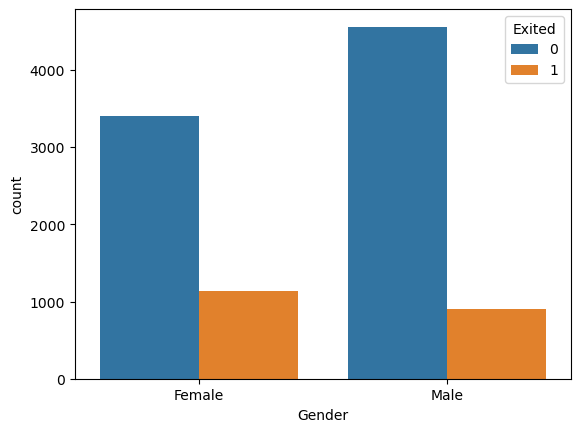

In [ ]:
# 4. Gender vs Churn
sns.countplot(x='Gender', hue='Exited', data=df)  

<Axes: xlabel='Geography', ylabel='count'>

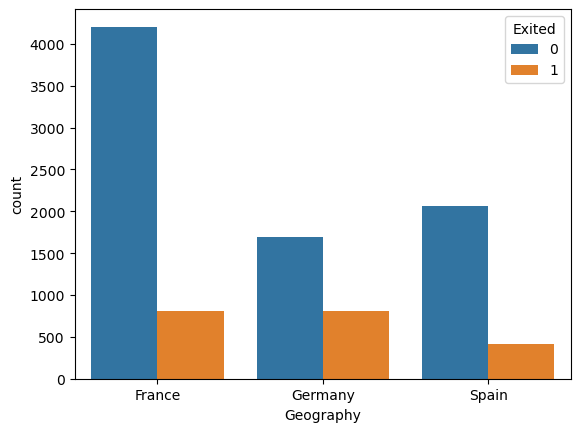

In [ ]:
# 5. Geography vs Churn
sns.countplot(x='Geography', hue='Exited', data=df) 

Correlation Analysis

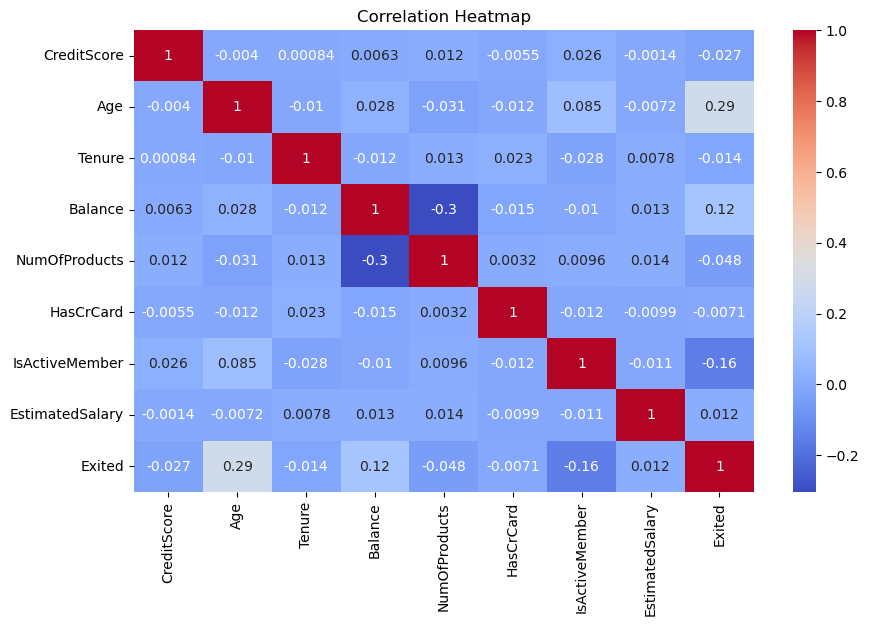

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Insights:

- The analysis shows that churned customers are generally older, have higher account balances, and are less active compared to retained customers.

- Geography significantly impacts churn, with some regions showing higher churn rates than others.

- Customers using only one bank product tend to churn more, indicating lower engagement with bank services.

- Inactive members and customers with lower credit scores display a higher likelihood of exiting the bank.

- Overall, churn is influenced by a combination of demographics, activity level, and financial behavior.